In [1]:
from TDS import run_simulation
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json

In [2]:
currents = []
z_coordinates_arr = []
dz_values = []
l_dipole_arr = np.linspace(0.3, 2, 33)
for l_dipole in l_dipole_arr:
    current, z_coordinates, dz = run_simulation(l_dipole)
    currents.append(current)
    z_coordinates_arr.append(z_coordinates)
    dz_values.append(dz)

100%|██████████| 1212/1212 [00:18<00:00, 64.90it/s]


In [3]:
def my_json_save(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(data, file, ensure_ascii=False, indent=4)

def my_json_load(path):
    with open(path, 'r', encoding='utf-8') as file:
        return json.load(file)

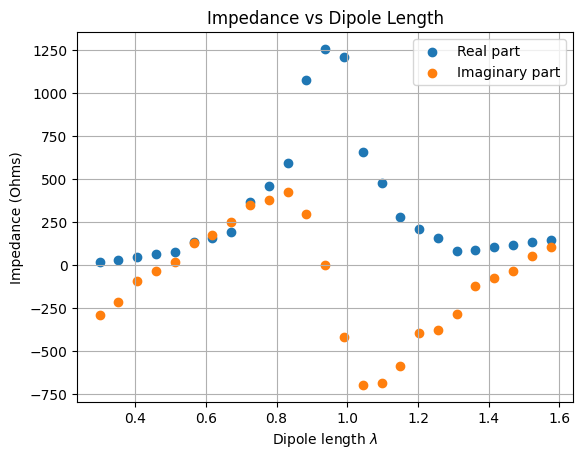

In [4]:
dz = dz_values[0] #dz одинаковый для всех симуляций
impedance = np.array([dz/current[len(current)//2]*1j for current in currents])
plt.scatter(l_dipole_arr[:25], impedance[:25].real, label='Real part')
plt.scatter(l_dipole_arr[:25], impedance[:25].imag, label='Imaginary part')
plt.xlabel(r'Dipole length $\lambda$')
plt.ylabel('Impedance (Ohms)')
plt.title('Impedance vs Dipole Length')
plt.legend()
plt.grid()
plt.show()

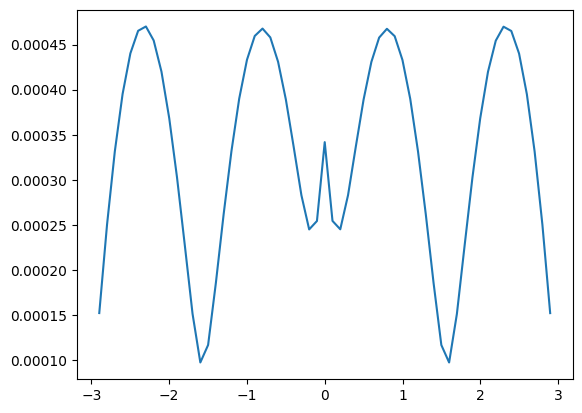

In [36]:
plt.plot(z_coordinates, np.abs(currents[-1])*2)

In [2]:
currents = []
z_coordinates_arr = []
dz_values = []
l_dipole_arr = np.array([0.5, 0.95, 1.5, 1.95])
for l_dipole in l_dipole_arr:
    current, z_coordinates, dz = run_simulation(l_dipole)
    currents.append(current)
    z_coordinates_arr.append(z_coordinates)
    dz_values.append(dz)

100%|██████████| 1212/1212 [00:18<00:00, 64.97it/s]


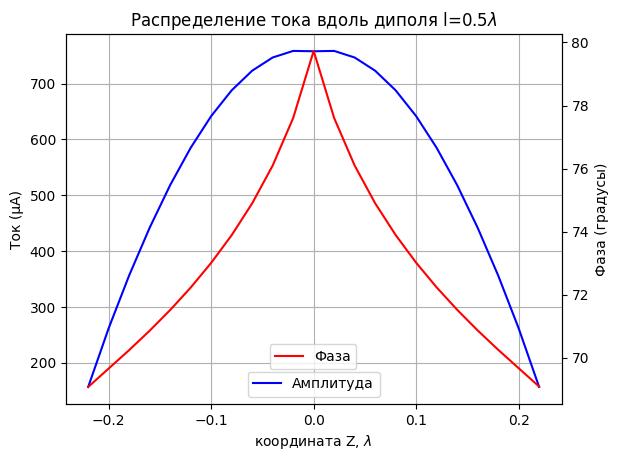

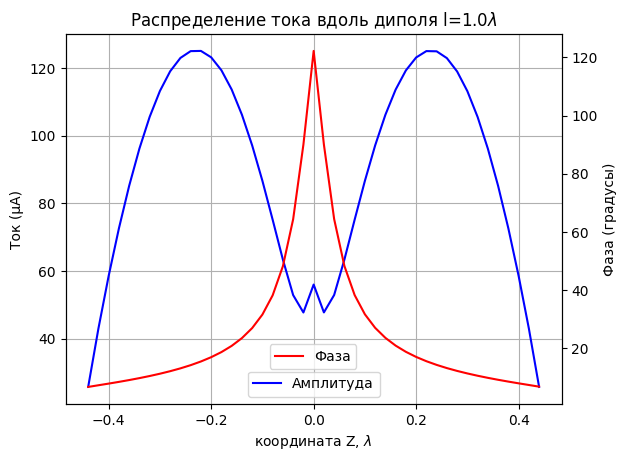

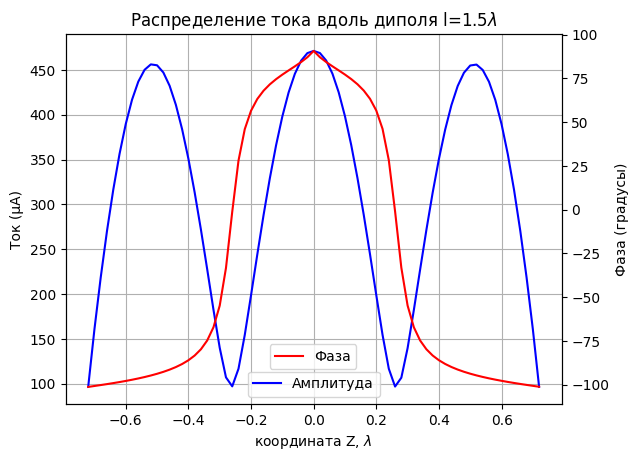

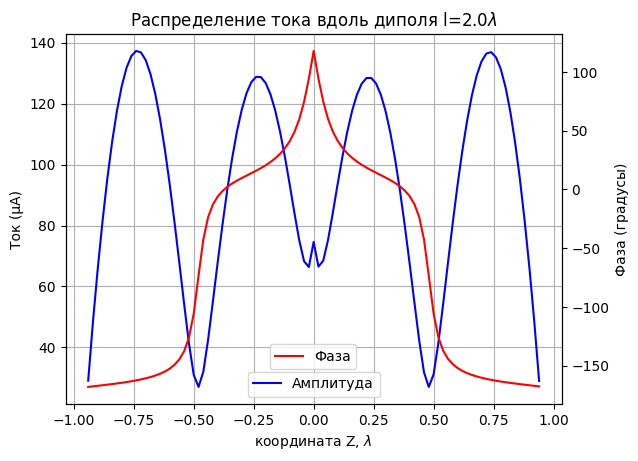

In [14]:
labels = ['l='+ f'{i*0.5:0.1f}' r'$\lambda$' for i in range(1, len(l_dipole_arr)+1)]
for i in range(len(l_dipole_arr)):
    fig, ax = plt.subplots()
    ax.plot(z_coordinates_arr[i]/3, np.abs(currents[i])*1.e6, label='Амплитуда', color='blue')
    ax2 = ax.twinx()
    ax2.plot(z_coordinates_arr[i]/3, 180/np.pi*np.angle(currents[i]), label='Фаза', color='red')
    ax2.set_ylabel('Фаза (градусы)')
    ax.set_xlabel(r'координата Z, $\lambda$')
    ax.set_ylabel('Ток (μA)')
    ax.set_title('Распределение тока вдоль диполя ' + labels[i])
    ax.legend(loc ='lower center')
    ax2.legend(bbox_to_anchor=(0.6, 0.18))
    ax.grid()
    plt.show()

In [4]:
def dipole_far_field_from_current(I_z, z_coords, lamb, theta):
    k = 2 * np.pi / lamb
    dz = np.mean(np.diff(z_coords)) if len(z_coords) > 1 else 1.0

    F = np.zeros_like(theta, dtype=np.complex128)
    for i, th in enumerate(theta):
        phase = np.exp(1j * k * z_coords * np.cos(th))
        F[i] = np.sum(I_z * phase) * dz

    E_theta = np.sin(theta) * F
    return E_theta

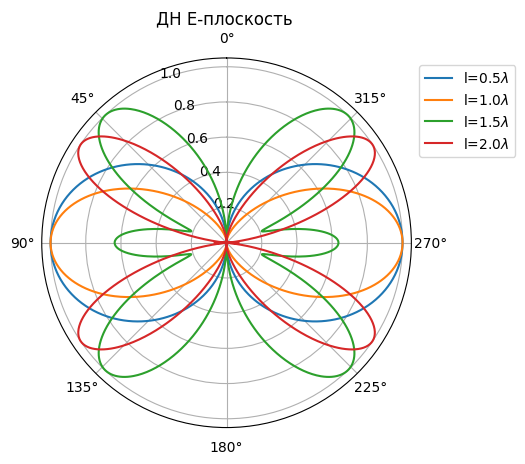

In [19]:
theta = np.linspace(0, 2*np.pi, 1001)
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
for i in range(len(l_dipole_arr)):
    #fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    E_theta = dipole_far_field_from_current(currents[i], z_coordinates_arr[i], 3, theta)
    pattern = np.abs(E_theta)
    pattern /= pattern.max()
    ax.set_theta_zero_location(loc='N')
    ax.plot(theta, pattern, label=labels[i])
    ax.set_title("ДН E-плоскость ")

ax.legend(loc = 'upper right', bbox_to_anchor=(1.3, 1.0))
plt.show()